# Analyze BBP hippocampus simulation

In this notebook, we will analyze one simulation performed at the Blue Brain Project and published in Romani et al. (2024). This simulation is part of a large set of simulations run with the intent of finding the best parameters to induce theta oscillations in the rat CA1.

The best set of parameters can be summized as follows:
1) External calcium concentration was set to 1 mM to mimic _in vivo_-like conditions
2) All the neurons were stimulationed with a depolarization of 120% (where a stimulation of 100% correspond to the voltage threshold for spike generation)
3) Application of ACh of 1 µM which affects both neuron excitability and synapse release probability
4) PV+ neurons were sitmulated with an oscillatory current of amplitude 0.2 nA and frequency 8 Hz

## Loading

In [2]:
import obi_auth
from entitysdk.client import Client
from entitysdk.models import Simulation, SimulationCampaign, SimulationResult, SimulationExecution
from entitysdk.common import ProjectContext
from entitysdk import models
from entitysdk.utils.store import LocalAssetStore
from obi_notebook.get_projects import get_projects
from obi_notebook.get_environment import get_environment
from uuid import UUID

from rich import print as rprint
from pathlib import Path
import shutil

import bluepysnap
import matplotlib.pyplot as plt
import numpy as np

Get authentication token and choose project __BBP hippocampus simulations__

In [3]:
env = "production"

token = obi_auth.get_token(environment=env, auth_mode="daf")

proj = get_projects(token=token, env=env)

Device Authentication Required

1. Click on authentication URL
2. Complete authentication in browser
3. Return here when done

Authentication URL:
]8;id=8617956;https://cell-a.openbraininstitute.org/auth/realms/SBO/device?user_code=XSBN-XNRH\https://cell-a.openbraininstitute.org/auth/realms/SBO/device?user_code=XSBN-XNRH]8;;\

   ✓ Authentication completed successfully!


Dropdown(description='Select:', options=(('Testing', {'id': '5ce8c7db-8847-499b-89b2-95612edafad2', 'name': 'T…

Initialize the client with the token and project context

In [4]:
client = Client(project_context=proj, environment=env, token_manager=token, local_store=LocalAssetStore(prefix="/data"))

In [5]:
from entitysdk.staging.simulation import stage_simulation
from entitysdk.staging.simulation_result import stage_simulation_result

def stage_single_sim_campaign(simulation_campaign_id, output_dir):
    simulation_campaign = client.get_entity(entity_type=SimulationCampaign, entity_id=simulation_campaign_id)
    simulation_id = simulation_campaign.simulations[0].id
    simulation = client.get_entity(entity_type=Simulation, entity_id=simulation_id)
    
    simulation_execution = client.search_entity(
                entity_type=SimulationExecution,
                query={"used__id": simulation.id}
            ).all()[0]
    
    simulation_result_id = simulation_execution.generated[0].id
    simulation_result = client.get_entity(entity_type=SimulationResult, entity_id=simulation_result_id)
    
    simulation_config_path = stage_simulation_result(
        client=client,
        model=simulation_result,
        output_dir=output_dir,
        simulation_config_file=None,
    )

    return simulation_config_path

In [6]:
simulation_campaign_id = UUID('47756f30-67c9-4c43-a2f3-75e36318f78f')

simulation_campaign = client.get_entity(entity_type = models.SimulationCampaign, entity_id = simulation_campaign_id)
# rprint(simulation_campaign)

In [7]:
show_details = True

# Get campaign information
circuit = client.get_entity(entity_id=simulation_campaign.entity_id, entity_type=models.Circuit)
print(f"Loaded campaign '{simulation_campaign.name}' (ID {simulation_campaign.id}):\n")
print(simulation_campaign.description)
print()
print(f"Circuit: '{circuit.name}' (ID {circuit.id})\n")
print(f"Number of simulations: {len(simulation_campaign.simulations)}\n")
print("Scan parameters:")
print("\n".join([f"  {k}: {v}" for k, v in simulation_campaign.scan_parameters.items()]))

# Show campaign details (optional)
if show_details:
    print("\nList of simulations:")
    for sim in simulation_campaign.simulations:
        sim = client.get_entity(entity_id=sim.id, entity_type=models.Simulation)  # To get assets!!
        print(f"  Simulation '{sim.name}' (ID {sim.id}): ")
        print(f"    {sim.scan_parameters}")

Loaded campaign 'ms-input' (ID 47756f30-67c9-4c43-a2f3-75e36318f78f):

my-campaign-description

Circuit: 'rCA1' (ID 78291026-6e9b-46ba-ba50-651b499cdd44)

Number of simulations: 1

Scan parameters:


List of simulations:
  Simulation 'sim-13' (ID 73f2bbfb-0c92-4c65-979a-ee4d228b5aac): 
    {}


In [8]:
simulation_campaign_id=simulation_campaign.id
output_dir = "./simulation_result_0"

if Path(output_dir).exists():
    shutil.rmtree(Path(output_dir))

simulation_path = stage_single_sim_campaign(simulation_campaign_id, output_dir=output_dir)

In [9]:
simulation = bluepysnap.Simulation(simulation_path)

In [10]:
simulation.reports

{'soma': <bluepysnap.frame_report.SomaReport at 0x7f47cd01d730>}

In [11]:
soma_report = simulation.reports['soma']

In [12]:
print(
    soma_report.time_start, 
    soma_report.time_stop, 
    soma_report.dt,
    soma_report.time_units
)

dt from the report differs from the global simulation dt.


0.0 20000.0 0.1 ms


In [13]:
soma_report.population_names

['hippocampus_neurons']

In [14]:
soma_pop = soma_report['hippocampus_neurons']

## Raster plot

<Axes: xlabel='Time [ms]', ylabel='nodes'>

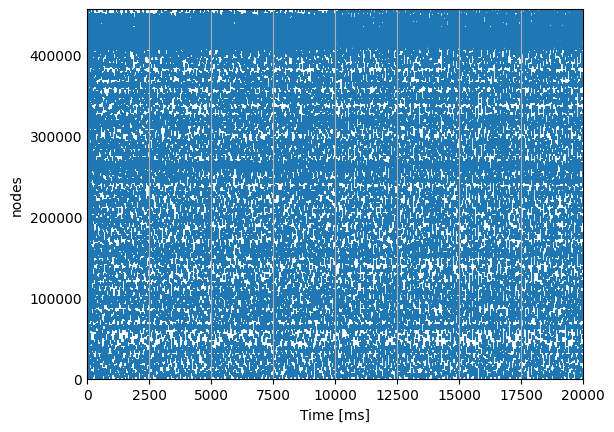

In [15]:
spikes = simulation.spikes
spikes.filter().raster()

## Plot traces

In [16]:
ids = soma_pop.resolve_nodes(group={'synapse_class':'EXC'})


In [17]:
filtered = soma_report.filter(group={'synapse_class':'EXC'}, t_start=19000, t_stop=20000)
df = filtered.report
df.head()

hippocampus_neurons                                              \
                     1710       1733       1790       1926       1997     
19000.0          -61.256020 -60.066532 -64.211792 -61.092735 -61.817257   
19000.1          -61.257278 -60.066055 -64.209335 -61.084381 -61.813534   
19000.2          -61.258778 -60.068420 -64.206604 -61.077606 -61.809376   
19000.3          -61.260418 -60.072720 -64.203568 -61.071629 -61.804859   
19000.4          -61.262154 -60.078526 -64.200256 -61.066174 -61.800022   

                                                                ...  \
            2124       2149       2219       2250       2497    ...   
19000.0 -61.900177 -59.813572 -61.071194 -60.100060 -59.394508  ...   
19000.1 -61.898205 -59.809521 -61.067814 -60.093731 -59.386189  ...   
19000.2 -61.895462 -59.806454 -61.065147 -60.091812 -59.382797  ...   
19000.3 -61.892303 -59.804066 -61.062901 -60.092525 -59.382328  ...   
19000.4 -61.888878 -59.802216 -61.060936 -60.095131 -59.384003  ...   

                                                                           \
            407581     407638     407762     407903     407914     407941   
19000.0 -60.580246 -61.935635 -58.293678 -63.860947 -61.860619 -58.873547   
19000.1 -60.578178 -61.940891 -58.289402 -63.851360 -61.858295 -58.867310   
19000.2 -60.576130 -61.942532 -58.284702 -63.842888 -61.856396 -58.860287   
19000.3 -60.573944 -61.941925 -58.279747 -63.834949 -61.854744 -58.852867   
19000.4 -60.571590 -61.939686 -58.274609 -63.827305 -61.853271 -58.845219   

                                                     
            407965     407979     408228     408276  
19000.0 -60.962852 -63.186501 -60.770912 -62.511688  
19000.1 -60.961212 -63.188896 -60.764309 -62.504585  
19000.2 -60.961624 -63.187866 -60.760288 -62.495808  
19000.3 -60.963230 -63.184757 -60.757847 -62.485786  
19000.4 -60.965694 -63.180161 -60.756550 -62.474743  

[5 rows x 5536 columns]

In [18]:
ids = df.columns.get_level_values(1).values
n_sample = 10
sel_ids = np.random.choice(ids, n_sample, replace=False)

In [19]:
df_sampled = df.loc[:, df.columns.get_level_values(1).isin(sel_ids)]
df_sampled.head()

hippocampus_neurons                                              \
                     48175      59696      99916      109896     121330   
19000.0          -62.611534 -62.785446 -62.307049 -59.797482 -57.867325   
19000.1          -62.616768 -62.784824 -62.298073 -59.794975 -57.862251   
19000.2          -62.619579 -62.784039 -62.287617 -59.796318 -57.856228   
19000.3          -62.621078 -62.783115 -62.276043 -59.800114 -57.849792   
19000.4          -62.621719 -62.782070 -62.263512 -59.805733 -57.843128   

                                                                
            149000     150467     239794     308070     374832  
19000.0 -63.436939 -63.285603 -60.752739 -62.061466 -59.136185  
19000.1 -63.436256 -63.282661 -60.750988 -62.055443 -59.137371  
19000.2 -63.434086 -63.278996 -60.747078 -62.051388 -59.135662  
19000.3 -63.430992 -63.274929 -60.741898 -62.048637 -59.132019  
19000.4 -63.427212 -63.270569 -60.735813 -62.046844 -59.126881

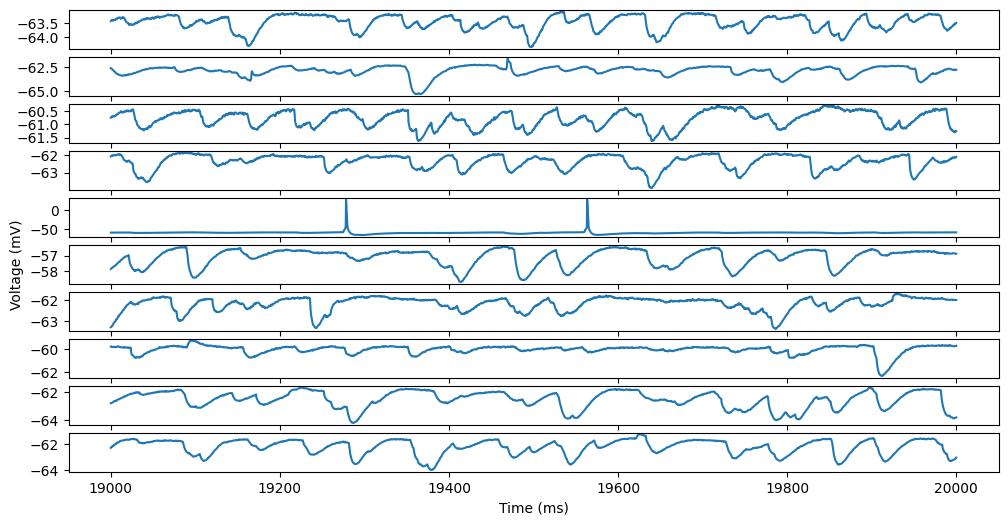

In [20]:
fig, axs = plt.subplots(n_sample, figsize=(12, 6), sharex=True)

x = df.index.values
for idx, sel_id in enumerate(sel_ids):
    y = df['hippocampus_neurons'][sel_id].values
    axs[idx].plot(x, y)
    if idx == round(n_sample/2):
        axs[idx].set_ylabel('Voltage (mV)')

axs[idx].set_xlabel('Time (ms)')

plt.show()

## References
Romani A, Antonietti A, Bella D, Budd J, Giacalone E, Kurban K, Sáray S, Abdellah M, Arnaudon A, Boci E, Colangelo C, Courcol JD, Delemontex T, Ecker A, Falck J, Favreau C, Gevaert M, Hernando JB, Herttuainen J, Ivaska G, Kanari L, Kaufmann AK, King JG, Kumbhar P, Lange S, Lu H, Lupascu CA, Migliore R, Petitjean F, Planas J, Rai P, Ramaswamy S, Reimann MW, Riquelme JL, Román Guerrero N, Shi Y, Sood V, Sy MF, Van Geit W, Vanherpe L, Freund TF, Mercer A, Muller E, Schürmann F, Thomson AM, Migliore M, Káli S, Markram H. Community-based reconstruction and simulation of a full-scale model of the rat hippocampus CA1 region. PLoS Biol. 2024 Nov 5;22(11):e3002861. doi: 10.1371/journal.pbio.3002861. PMID: 39499732; PMCID: PMC11537418.
https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.3002861